In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
import os
import pickle
from scipy.stats import spearmanr
import matplotlib.font_manager as fm
# Import custom utility functions
from utils import (birth_calculation, death_calculation, datenum_to_datetime, datetime_to_datenum, fillNaN_columns)
fontpath='./data/Arial.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 10,
    'lines.linewidth': 1.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5
})
plt.rcParams['font.family'] = 'Arial'
# Suppress warnings
warnings.filterwarnings('ignore')
plt.rcParams["pdf.fonttype"] = 42


# Load Data

In [2]:
f='./data/Canada_data.pkl'
with open(f, 'rb') as file:
    Canada_data = pickle.load(file)
infection_data = pd.read_csv(f'./data/confinmed_case_Canada.csv')
vac_data       = pd.read_csv(f'./data/vaccine_Canada.csv')
phi_data       = pd.read_csv(f'./data/smoothed_phi_estimates_Canada.csv')
cluster_colors = pd.read_csv('./data/cluster_colors.csv')
D_mean_data    = pd.read_csv('./data/cluster_mean_distance_matrix.csv')
B_data         = pd.read_csv('./data/binding_average_per_cluster.csv')
print(f"Infection data shape: {infection_data.shape}")
print(f"Vaccination data shape: {vac_data.shape}")

Infection data shape: (1950, 3)
Vaccination data shape: (1269, 6)


# Data Preprocessing and Merging

In [3]:
phi_data['Day'] = pd.to_datetime( phi_data['date'],format="%Y-%m-%d")
infection_data['Day'] = pd.to_datetime(infection_data['Day'],format="%Y-%m-%d")
vac_data['Day'] = pd.to_datetime(vac_data['Day'],format="%Y-%m-%d")
tmp = pd.merge(infection_data,vac_data,on='Day',how='outer',sort=True)
infection_vac_data = pd.merge(tmp,phi_data,on='Day',how='outer',sort=True)

In [4]:
# Process binding and distance data
B = B_data.iloc[:, 1].values
D = D_mean_data.iloc[0:, 1:].values.astype(float)
np.fill_diagonal(D, 0)  # Set diagonal to zero (self-distance)
# Extract distances between variants and vaccine types
ind_wt=0
ind_ba5=6
ind_ba1=3
ind_XBB=8
D_vac = D[:, [ind_wt, ind_wt, ind_ba1, ind_XBB]]  # Indices adjusted for 0-based
# For bivalent vaccine, use minimum distance principle
D_vac[:, 2] = np.minimum(D_vac[:, 0], D_vac[:, 2])

# Vaccination and infection

In [5]:
# Convert dates to numeric format and prepare time series
covariate_time = pd.to_datetime(infection_vac_data['Day']).apply(lambda x: datetime_to_datenum(x)).values
# Calculate cumulative infection rate (per million, converted to proportion)
N_rate_ave = infection_vac_data[ 'Daily new confirmed cases of COVID-19 per million people (rolling 7-day average, right-aligned)'  ].fillna(0).cumsum() / 1000000 
phi_rate=infection_vac_data['smoothed_phi'].fillna(0).cumsum() 
# Extract vaccination data (convert from percentage to proportion)
vac_fully = infection_vac_data['People fully vaccinated (cumulative, per hundred)'] / 100
vac_booster = infection_vac_data['Booster doses (cumulative, per hundred)']/ 100
vac_all = infection_vac_data['COVID-19 doses (cumulative, per hundred)'] / 100
print(f"Time series length: {len(covariate_time)}")
print(f"Date range: {infection_vac_data['Day'].iloc[0]} to {infection_vac_data['Day'].iloc[-1]}")

Time series length: 1956
Date range: 2020-01-09 00:00:00 to 2025-05-17 00:00:00


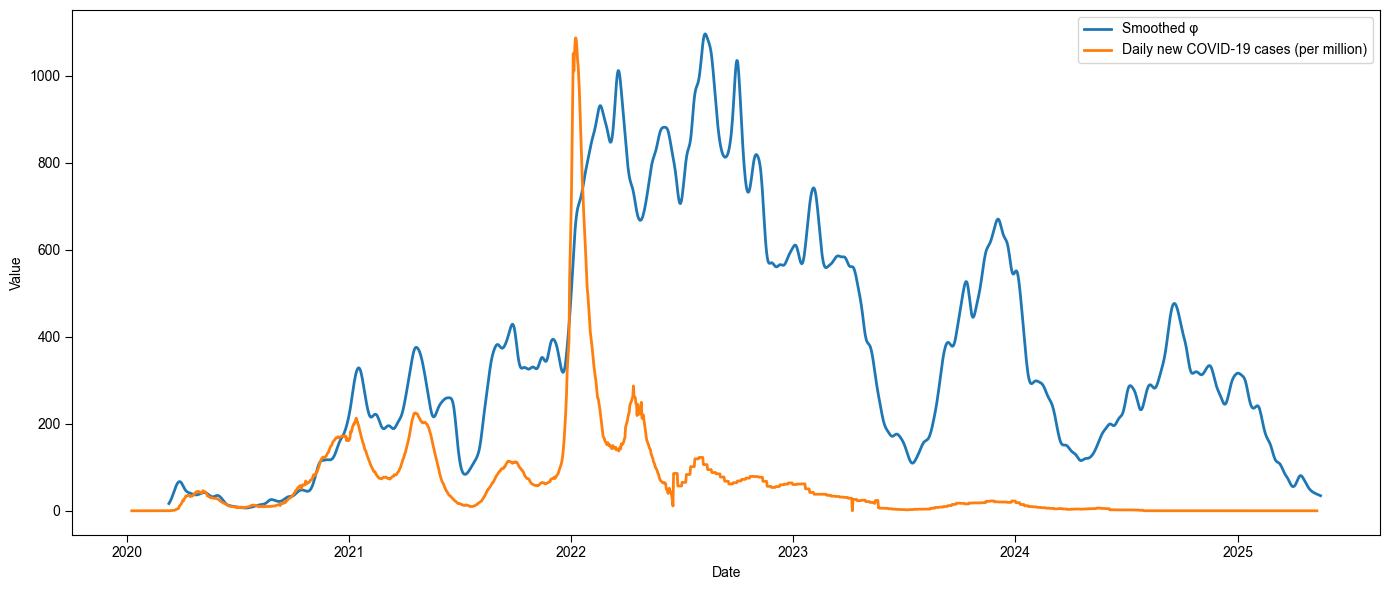

In [6]:
plt.figure(figsize=(14, 6))
# smoothed_phi curve
plt.plot(infection_vac_data['Day'],infection_vac_data['smoothed_phi'],label='Smoothed φ',linewidth=2)
# infection curve
plt.plot(
    infection_vac_data['Day'],
    infection_vac_data['Daily new confirmed cases of COVID-19 per million people (rolling 7-day average, right-aligned)'],
    label='Daily new COVID-19 cases (per million)',
    linewidth=2
)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Vaccination Data Processing

In [7]:
# Define key dates for different vaccine types
t_bivalent=datetime_to_datenum(datetime.strptime("2022-09-20", "%Y-%m-%d"))
t_XBB=datetime_to_datenum(datetime.strptime("2023-09-20", "%Y-%m-%d"))
ind_bivalent = np.where(covariate_time == 738792)[0][0]  # 28-Sep-2022
ind_XBB_vac = np.where(covariate_time == 739142)[0][0]      # 13-Sep-2023
# Initialize arrays for each vaccine type
vac_bivalent = np.zeros(len(covariate_time))
vac_XBB = np.zeros(len(covariate_time))
# Calculate bivalent vaccine uptake
vac_bivalent[ind_bivalent:] = vac_booster.iloc[ind_bivalent:] - vac_booster.iloc[ind_bivalent]
vac_booster.iloc[ind_bivalent:] = vac_booster.iloc[ind_bivalent]
# Calculate XBB vaccine uptake
vac_XBB[ind_XBB_vac:] = vac_bivalent[ind_XBB_vac:] - vac_bivalent[ind_XBB_vac]
vac_bivalent[ind_XBB_vac:] = vac_bivalent[ind_XBB_vac]
# Combine all vaccination data
vac = np.column_stack([vac_fully.values, vac_booster.values, vac_bivalent, vac_XBB])
vac_fill = fillNaN_columns(vac)

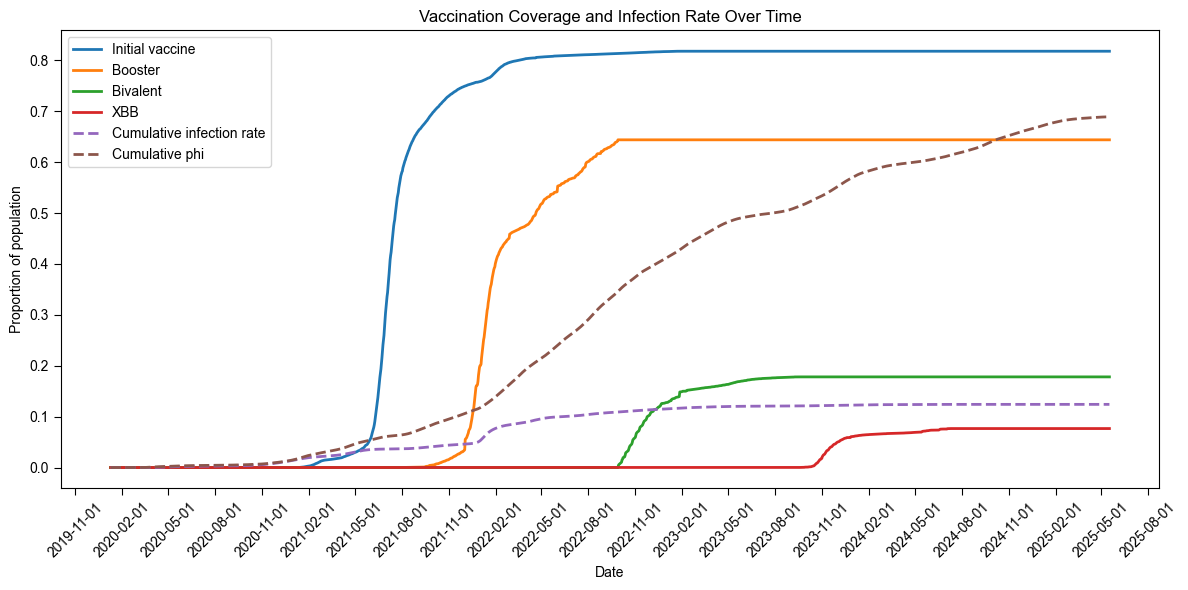

In [8]:
plt.figure(figsize=(12, 6))
# Convert datenum to datetime for plotting
dates = [datenum_to_datetime(t) for t in covariate_time]
plt.plot(dates, vac_fill[:, 0], label='Initial vaccine', linewidth=2)
plt.plot(dates, vac_fill[:, 1], label='Booster', linewidth=2)
plt.plot(dates, vac_fill[:, 2], label='Bivalent', linewidth=2)
plt.plot(dates, vac_fill[:, 3], label='XBB', linewidth=2)
plt.plot(dates, N_rate_ave, label='Cumulative infection rate', linewidth=2, linestyle='--')
plt.plot(dates, phi_rate/1000000, label='Cumulative phi', linewidth=2, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Proportion of population')
plt.title('Vaccination Coverage and Infection Rate Over Time')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Population


In [9]:
population_data = pd.read_csv('./data/population_most_recently.csv')
population_dict = dict(zip(population_data['Entity'], population_data['Population (historical)']))
P = population_dict.get('Canada')
# Define time span for analysis
t0 = 737851      # Start date in datenum format
t_end = 739720   # End date in datenum format
tspan = [t0, t_end]

## Birth index calculation

In [10]:
freq_0 = 0.001
x_obs_ave = Canada_data['x_obs_smooth']
time_obs=Canada_data['dates']
n_sum_ave=Canada_data['n_sum_smooth']
global_cluster_count = x_obs_ave.shape[1] 
birth_index = birth_calculation(x_obs_ave, freq_0, 3)
val_cluster = birth_index > 0
x_obs_ave_valid = x_obs_ave.T  
death_index = death_calculation(x_obs_ave_valid.T, 0.001)
for i in range(global_cluster_count):
    if birth_index[i] > 0:  # effective variants
        x_obs_ave_valid[i, :birth_index[i]-1] = 0
        if death_index[i] > 0:
            x_obs_ave_valid[i, death_index[i]-1:] = 0
    else:  
        x_obs_ave_valid[i, :] = 0
row_sums = x_obs_ave_valid.sum(axis=0)
row_sums[row_sums == 0] = 1  
x_obs_ave_valid = x_obs_ave_valid / row_sums
T=time_obs.shape[0]

# Fixed parameters

In [11]:
colors = cluster_colors['Color'].values
tau=360 #half-life
lambda_=np.log(2)/tau
c_ad=8.0706 #ratio between dms and assay based antigenic distance
k= 3.1 #protection vs neutralization foldchange
r= np.log2(10)/(c_ad*k)

# Immunity trajectory

In [12]:
X_t=x_obs_ave_valid
deltat=7
T=time_obs.shape[0]
n_cluster=x_obs_ave.shape[1]
phi_array = []
vac_array = []
vac_data=vac_fill * P
phi_data=infection_vac_data['smoothed_phi'].values
daily_vac = np.diff(vac_data, axis=0)
daily_vac = np.vstack([np.zeros((1, vac_data.shape[1])), daily_vac])
for t in time_obs:
    # 找到 covariate_time 落在 [t, t+deltat) 内的索引
    mask = (covariate_time >= t-deltat) & (covariate_time < t )
    # 对应区间内的 phi 求和
    phi_sum = phi_data[mask].sum() #nromalization
    vac_sum=daily_vac[mask].sum(axis=0)
    phi_array.append(phi_sum)
    vac_array.append(vac_sum)

phi_array = np.array(phi_array)
vac_array = np.array(vac_array)
min_val = np.nanmin(phi_array)
phi_array = np.where(np.isnan(phi_array), min_val, phi_array)
inf_num=phi_array[:, None]*X_t.T* P/1000000 #T*S
idx = np.arange(T)
diff = np.subtract.outer(idx, idx)        
W=np.tril(np.exp(-diff * deltat * lambda_))   
I=W@inf_num #T*S
I_vac=W@vac_array

# Empirical fitness with variability

In [13]:
#empirical fitness
n_t=np.array(n_sum_ave.copy())
X_t_pre=X_t[:,0:-1]
X_t_post=X_t[:,1:]
log_X_FC = np.log(np.where(X_t_pre != 0, X_t_post / X_t_pre, np.nan))
f_emp= np.full((n_cluster,T), np.nan)
f_emp[:,:-1]=log_X_FC/(deltat)
J=1000
X_resample= np.zeros((n_cluster, T, J))
phi = 1100
for t in range(T):
    p = X_t[:, t]
    alpha = np.maximum(p, 1e-12) * phi
    Pj = np.random.dirichlet(alpha, size=J)   # (J, n_cluster)

    X_resample_t = np.empty((J, n_cluster), dtype=float)
    nt = int(n_t[t])
    for j in range(J):
        X_resample_t[j] = np.random.multinomial(nt, Pj[j]) / nt
    X_resample[:, t, :] = X_resample_t.T
X_t_pre_resample=X_resample[:,0:-1,:]
X_t_post_resample=X_resample[:,1:,:]
log_X_FC_resample = np.log(np.where(X_t_pre_resample != 0, X_t_post_resample / X_t_pre_resample, np.nan))
f_emp_resample= np.full((n_cluster,T,J), np.nan)
f_emp_resample[:,:-1,:]=log_X_FC_resample/(deltat)
f_emp_std=np.nanstd(f_emp_resample, axis=2)
sigma0 = np.nanmedian(f_emp_std)
f_emp_std_w = np.sqrt(f_emp_std**2 + sigma0**2)

#model fitness
C = np.exp(-D / r)
S = C @ I.T
C_vac = np.exp(-D_vac / r)
S_vac = C_vac @ I_vac.T
F_int = np.tile( B[:,None],(1,T))
F_inf=- S / P 
F_vac=- S_vac / P
cols = np.arange(T)[None, :] 
cluster_id=np.tile(np.arange(n_cluster)[:, None], (1, T))

# data split
T_train=148
mask_train = (X_t > 0.01) & (X_t < 1) & (cols >= 0) & (cols<= T_train)
mask_test = (X_t > 0.01) & (X_t < 1) & (cols > T_train) & (cols<= T)
F_int_ave=np.sum(F_int*X_t ,axis=0)
F_inf_ave=np.sum(F_inf*X_t,axis=0)
F_vac_ave=np.sum(F_vac*X_t,axis=0)
l_int=F_int-F_int_ave
l_inf=F_inf-F_inf_ave
l_vac=F_vac-F_vac_ave
mask2=np.isfinite(f_emp)& (np.isfinite(f_emp_std))
l_int_val=l_int[mask_train&mask2]
l_inf_val=l_inf[mask_train&mask2]
l_vac_val=l_vac[mask_train&mask2]
f_emp_val=f_emp[mask_train&mask2]
f_emp_std_val=f_emp_std_w[mask_train&mask2]
cluster_id_val=cluster_id[mask_train&mask2]
l_int_val_test=l_int[mask_test&mask2]
l_inf_val_test=l_inf[mask_test&mask2]
l_vac_val_test=l_vac[mask_test&mask2]
f_emp_val_test=f_emp[mask_test&mask2]
f_emp_std_val_test=f_emp_std_w[mask_test&mask2]
cluster_id_val_test=cluster_id[mask_test&mask2]

# Model fitting

In [14]:
from scipy.optimize import nnls
A = np.column_stack((l_int_val, l_inf_val, l_vac_val))
n_obs=f_emp_val.shape[0]
A_noint=np.column_stack((l_inf_val, l_vac_val))
A_noinf=np.column_stack((l_int_val, l_vac_val))
A_novac=np.column_stack((l_int_val, l_inf_val))

A_test = np.column_stack((l_int_val_test, l_inf_val_test, l_vac_val_test))
A_test_noint = np.column_stack((l_inf_val_test, l_vac_val_test))
s, r_full = nnls(A/f_emp_std_val[:,None], f_emp_val/f_emp_std_val)

s_noint, r_noint = nnls(A_noint/f_emp_std_val[:,None], f_emp_val/f_emp_std_val)
s_noinf, r_noinf = nnls(A_noinf/f_emp_std_val[:,None], f_emp_val/f_emp_std_val)
s_novac, r_novac = nnls(A_novac/f_emp_std_val[:,None], f_emp_val/f_emp_std_val)

Lik=-0.5*r_full**2
Lik_noint=-0.5*r_noint**2
Lik_noinf=-0.5*r_noinf**2
Lik_novac=-0.5*r_novac**2
Lik_null=-0.5*np.linalg.norm(f_emp_val/f_emp_std_val)**2

d_Lik=Lik-Lik_null
d_Lik_noint=Lik_noint-Lik_null
d_Lik_noinf=Lik_noinf-Lik_null
d_Lik_novac=Lik_novac-Lik_null

d_BIC=-2*d_Lik+3*np.log(n_obs)
d_BIC_noint=-2*d_Lik_noint+2*np.log(n_obs)
d_BIC_noinf=-2*d_Lik_noinf+2*np.log(n_obs)
d_BIC_novac=-2*d_Lik_novac+2*np.log(n_obs)

f_pred=A@s
f_pred_test=A_test@s

r_all=(f_pred-f_emp_val)/f_emp_std_val

f_pred_noint=A_noint@s_noint
f_pred_test_noint=A_test_noint@s_noint

s_resample=np.full((3,J),np.nan)
s_resample_noint=np.full((2,J),np.nan)
s_resample_noinf=np.full((2,J),np.nan)
s_resample_novac=np.full((2,J),np.nan)
for i in range(J):
    f_emp_val_i=f_emp_resample[:,:,i][mask_train&mask2]
    if np.isfinite(f_emp_val_i).all():
        s_i, _ = nnls(A/f_emp_std_val[:,None], f_emp_val_i/f_emp_std_val)
        s_i_noint, _ = nnls(A_noint/f_emp_std_val[:,None], f_emp_val_i/f_emp_std_val)
        s_i_noinf, _ = nnls(A_noinf/f_emp_std_val[:,None], f_emp_val_i/f_emp_std_val)
        s_i_novac, _ = nnls(A_novac/f_emp_std_val[:,None], f_emp_val_i/f_emp_std_val)

        s_resample[:,i]=s_i
        s_resample_noint[:,i]=s_i_noint
        s_resample_noinf[:,i]=s_i_noinf
        s_resample_novac[:,i]=s_i_novac
    

s_std=np.nanstd(s_resample,axis=1)
s_std_noint=np.nanstd(s_resample_noint,axis=1)
s_std_noinf=np.nanstd(s_resample_noinf,axis=1)
s_std_novac=np.nanstd(s_resample_novac,axis=1)

f_pred_all=s[0]*l_int+s[1]*l_inf+s[2]*l_vac
f_pred_plot=f_pred_all
f_pred_plot[X_t<0.01]=np.nan
f_pred_all_noint=s_noint[0]*l_inf+s_noint[1]*l_vac
f_pred_plot_noint=f_pred_all_noint
f_pred_plot_noint[X_t<0.01]=np.nan


# Model comparision

In [15]:
def fmt_pm(val, std, prec=3):
    return f"{val:.{prec}f} ± {std:.{prec}f}"

rows = [
    {
        "model": "full",
        "s_int": fmt_pm(s[0], s_std[0]),
        "s_inf": fmt_pm(s[1], s_std[1]),
        "s_vac": fmt_pm(s[2], s_std[2]),
        "delta_logL": float(d_Lik),
        "delta_BIC": float(d_BIC),
    },
    {
        "model": "noint",
        "s_int": "",
        "s_inf": fmt_pm(s_noint[0], s_std_noint[0]),
        "s_vac": fmt_pm(s_noint[1], s_std_noint[1]),
        "delta_logL": float(d_Lik_noint),
        "delta_BIC": float(d_BIC_noint),
    },
    {
        "model": "noinf",
        "s_int": fmt_pm(s_noinf[0], s_std_noinf[0]),
        "s_inf": "",
        "s_vac": fmt_pm(s_noinf[1], s_std_noinf[1]),
        "delta_logL": float(d_Lik_noinf),
        "delta_BIC": float(d_BIC_noinf),
    },
    {
        "model": "novac",
        "s_int": fmt_pm(s_novac[0], s_std_novac[0]),
        "s_inf": fmt_pm(s_novac[1], s_std_novac[1]),
        "s_vac": "",
        "delta_logL": float(d_Lik_novac),
        "delta_BIC": float(d_BIC_novac),
    },
]
df = pd.DataFrame(rows, columns=["model","s_int","s_inf","s_vac","delta_logL","delta_BIC"])
df["delta_logL"] = df["delta_logL"].round(1)
df["delta_BIC"]  = df["delta_BIC"].round(1)
df


,model,s_int,s_inf,s_vac,delta_logL,delta_BIC
0,full,0.009 ± 0.001,0.896 ± 0.016,0.301 ± 0.011,205.8,-394.4
1,noint,,0.942 ± 0.015,0.293 ± 0.011,204.4,-397.4
2,noinf,0.032 ± 0.001,,0.503 ± 0.009,135.6,-259.8
3,novac,0.003 ± 0.001,1.166 ± 0.013,,174.4,-337.3


# Model performance

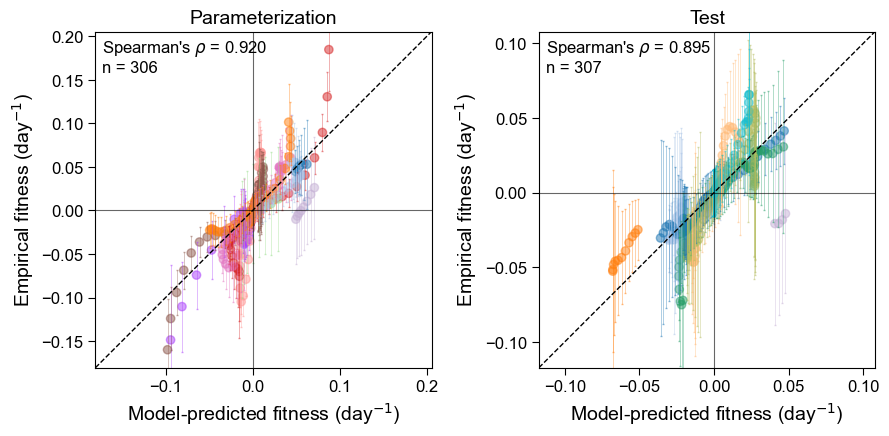

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5)) 
ax0 = ax[0]
ax0.scatter(f_pred_noint, f_emp_val, alpha=0.5,color=colors[cluster_id_val])
for cid in np.unique(cluster_id_val):
    mask = cluster_id_val == cid
    ax0.errorbar(
        f_pred_noint[mask],
        f_emp_val[mask],
        yerr=f_emp_std_val[mask],
        fmt='none',
        color=colors[cid],
        alpha=0.5,
        capsize=1,
        linewidth=0.5
    )
lo = min(f_pred_noint.min(), f_emp_val.min())
hi = max(f_pred_noint.max(), f_emp_val.max())
span = hi - lo if hi > lo else 1e-6
m = 0.06 * span
x0, x1 = lo - m, hi + m
r_s, _ = spearmanr(f_pred_noint, f_emp_val)
ax0.text(
    0.02, 0.98,
    f"Spearman's $\\rho$ = {r_s:.3f}\n"
    f"n = {f_pred_noint.shape[0]:.0f}\n",
    transform=ax0.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold'
)

ax0.plot([x0, x1], [x0, x1], 'k--', lw=1)
ax0.set_xlim(x0, x1)
ax0.set_ylim(x0, x1)
ax0.set_aspect('equal', adjustable='box')
ax0.set_xlabel(r'Model-predicted fitness (day$^{-1}$)', fontweight='bold',fontsize=14)
ax0.set_ylabel(r'Empirical fitness (day$^{-1}$)', fontweight='bold',fontsize=14)
ax0.tick_params(axis='both', which='major', labelsize=12)  
ax0.set_title("Parameterization",fontsize=14)
ax0.axhline(0, color='k', lw=0.8, alpha=0.6)
ax0.axvline(0, color='k', lw=0.8, alpha=0.6)


ax1 = ax[1]
ax1.scatter(f_pred_test_noint, f_emp_val_test, alpha=0.5,color=colors[cluster_id_val_test])
for cid in np.unique(cluster_id_val_test):
    mask = cluster_id_val_test == cid
    ax1.errorbar(
        f_pred_test_noint[mask],
        f_emp_val_test[mask],
        yerr=f_emp_std_val_test[mask],
        fmt='none',
        color=colors[cid],
        alpha=0.5,
        capsize=1,
        linewidth=0.5
    )
lo = min(f_pred_test_noint.min(), f_emp_val_test.min())
hi = max(f_pred_test_noint.max(), f_emp_val_test.max())
span = hi - lo if hi > lo else 1e-6
m = 0.3 * span
x0, x1 = lo - m, hi + m

r_s_test, _ = spearmanr(f_pred_test_noint, f_emp_val_test)
ax1.text(
    0.02, 0.98,
    f"Spearman's $\\rho$ = {r_s_test:.3f}\n"
    f"n = {f_pred_test_noint.shape[0]:.0f}",
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold'
)

ax1.plot([x0, x1], [x0, x1], 'k--', lw=1)
ax1.set_xlim(x0, x1)
ax1.set_ylim(x0, x1)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlabel(r'Model-predicted fitness (day$^{-1}$)', fontweight='bold',fontsize=14)
ax1.set_ylabel(r'Empirical fitness (day$^{-1}$)', fontweight='bold',fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)   # 主刻度
ax1.set_title("Test",fontsize=14)
ax1.axhline(0, color='k', lw=0.8, alpha=0.6)
ax1.axvline(0, color='k', lw=0.8, alpha=0.6)

plt.tight_layout()
outdir = "./figs"
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "fitness_test.pdf"),
        bbox_inches="tight")

plt.show()

# Dynamic immune and fitness landscape

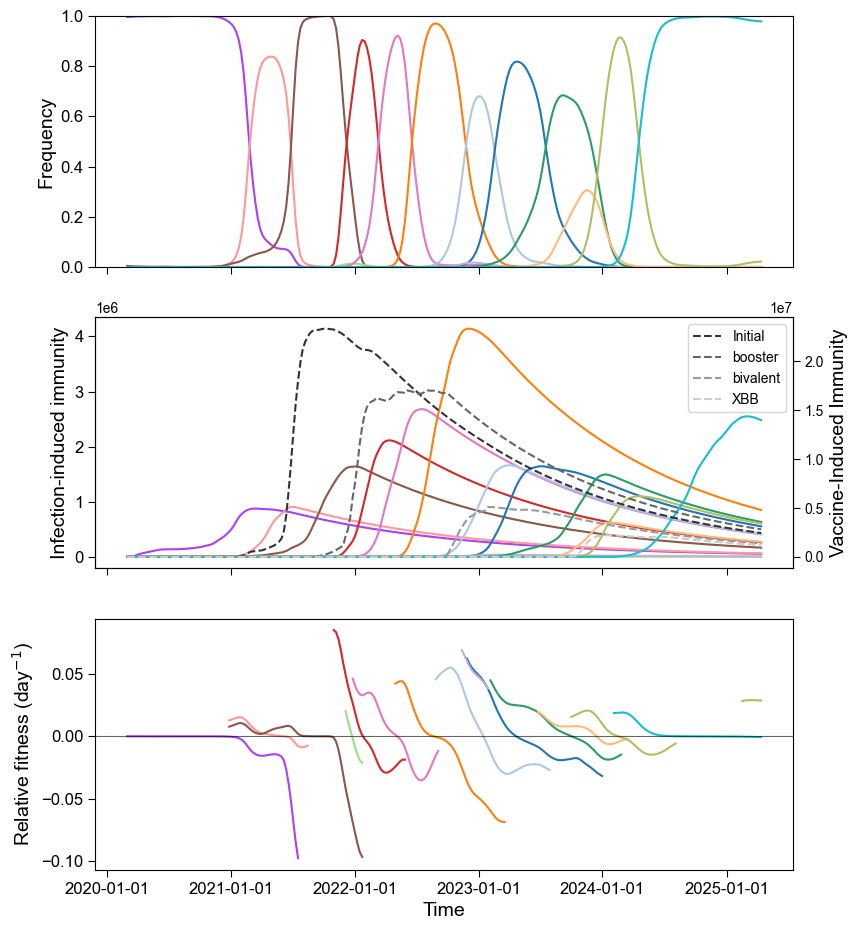

In [17]:
X_t_low, X_t_high = np.percentile(X_resample, [2.5, 97.5], axis=2)
# Create figure with subplots
fig = plt.figure(figsize=(9, 15))
# Convert timeline to datetime
dates_timeline = [datenum_to_datetime(int(t)) for t in time_obs]
# 2. Estimated frequencies + IQR
ax2 = plt.subplot(4, 1, 1)
for i in range(n_cluster):
    c = colors[i] if i < len(colors) else None
    ax2.plot(dates_timeline, X_t[i, :], color=c)
ax2.set_ylabel('Frequency', fontweight='bold',fontsize=14)
ax2.set_ylim([0, 1])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.tick_params(axis='x', rotation=45)
ax2.grid(False)
ax2.tick_params(axis='x', labelbottom=False)
ax2.tick_params(axis='both', which='major', labelsize=12)   # 主刻度

ax3 = plt.subplot(4, 1, 2)
for i in range(I.shape[1]):
    c = colors[i] if i < len(colors) else None
    ax3.plot(dates_timeline, I.T[i, :], color=c)
ax3.set_ylabel('Infection-induced immunity', fontweight='bold',fontsize=14)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax3.tick_params(axis='x', rotation=45)
ax3.grid(False)
ax3.tick_params(axis='x', labelbottom=False)
vaccine_labels=['Initial','booster','bivalent','XBB']
gray_colors = ['0.2', '0.4', '0.6', '0.8'] 
ax3_right = ax3.twinx()
for i in range(I_vac.shape[1]):
    g = gray_colors[i % len(gray_colors)]
    ax3_right.plot(dates_timeline, I_vac.T[i, :],
                   label=vaccine_labels[i],
                   linestyle='--',  # 虚线
                   color=g)
ax3_right.set_ylabel('Vaccine-Induced Immunity', fontweight='bold',fontsize=14)
handles, labels = ax3_right.get_legend_handles_labels()
ax3_right.legend(handles, labels, loc='upper right')
ax3.tick_params(axis='both', which='major', labelsize=12)   # 主刻度

# 5. Estimated fitness + IQR
ax5 = plt.subplot(4, 1, 3)
for i in range(n_cluster):
    c = colors[i] if i < len(colors) else None
    ax5.plot(dates_timeline, f_pred_plot[i, :], color=c)
ax5.tick_params(axis='x')
ax5.set_ylabel(r'Relative fitness (day$^{-1}$)', fontweight='bold',fontsize=14)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax5.set_xlabel("Time",fontsize=14)
ax5.tick_params(axis='both', which='major', labelsize=12)   # 主刻度
ax5.axhline(0, color='k', lw=0.8, alpha=0.6)
outdir = "./figs"
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "turnover.pdf"),
        bbox_inches="tight")

In [18]:
s_save = np.insert(s_noint, 0, 0)
model_data = {
    'time_obs': time_obs,
    'x_obs': x_obs_ave_valid,
    'phi': phi_array,
    'covaraite_time': covariate_time,
    'vac': vac_array,             
    'P': P,
    'n':n_t,
    's':s_save,
    'lambda':lambda_,
    'r':r,
    'I_vac':I_vac
}
with open('./data/model_data.pkl', 'wb') as f:
    pickle.dump(model_data, f)